**Name**: Devyani Sanjay Gurgude **Div**: SEDA **Roll**: 09 **PRN no**:1252090009

**Assignment No: 05**

Predict the price of the Uber ride from a given pickup point to the agreed drop-off location.
Perform following tasks:
1. Pre-process the dataset.
2. Identify outliers.
3. Check the
correlation.
4. Implement linear regression and ridge, Lasso regression models.
5. Evaluate the models and compare their respective scores like R2, RMSE, etc. Dataset link:
https://www.kaggle.com/datasets/yasserh/uber-fares-dataset


In [ ]:
import numpy as np
import pandas as pd
df=pd.read_csv("uber2.csv")
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [ ]:
df.shape

(200000, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         200000 non-null  int64  
 1   key                200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


In [ ]:
df.describe()

,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,2.000000e+05,200000.000000,200000.000000,200000.000000,199999.000000,199999.000000,200000.000000
mean,2.771250e+07,11.359955,-72.527638,39.935885,-72.525292,39.923890,1.684535
std,1.601382e+07,9.901776,11.437787,7.720539,13.117408,6.794829,1.385997
min,1.000000e+00,-52.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,1.382535e+07,6.000000,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,2.774550e+07,8.500000,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,4.155530e+07,12.500000,-73.967154,40.767158,-73.963658,40.768001,2.000000
max,5.542357e+07,499.000000,57.418457,1644.421482,1153.572603,872.697628,208.000000


**1. Pre-process the dataset**

1. Check Missing Values

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
key,0
fare_amount,0
pickup_datetime,0
pickup_longitude,0
pickup_latitude,0
dropoff_longitude,1
dropoff_latitude,1
passenger_count,0


2. Remove Missing Values

In [ ]:
df = df.dropna()


3. Check the values again

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
key,0
fare_amount,0
pickup_datetime,0
pickup_longitude,0
pickup_latitude,0
dropoff_longitude,0
dropoff_latitude,0
passenger_count,0


4. Remove Invalid Data

In [ ]:
df=df[df['fare_amount']>0]

In [ ]:
df=df[df['passenger_count']>0]

In [ ]:
df=df[(df['pickup_latitude']>=-90) & (df['pickup_latitude']<=90)]
df=df[(df['dropoff_latitude']>=-90) & (df['dropoff_latitude']<=90)]


In [ ]:
df = df[(df['pickup_longitude']>=-180) & (df['pickup_longitude']<=180)]
df = df[(df['dropoff_longitude']>=-180) & (df['dropoff_longitude']<=180)]


In [ ]:
print("New dataset shape:", df.shape)

New dataset shape: (199257, 9)


In [ ]:
df['pickup_datetime']=pd.to_datetime(df['pickup_datetime'],errors='coerce')

Data Transformation

In [ ]:
import numpy as np
df['distance'] = np.sqrt((df['dropoff_longitude'] - df['pickup_longitude'])**2
                         +(df['dropoff_latitude'] - df['pickup_latitude'])**2)


Remove Unnecessary Columns

In [ ]:
df.drop(['key', 'Unnamed: 0'], axis=1, inplace=True)

**2. Identify Outliers**

In [ ]:
df['fare_amount'].quantile([0.25, 0.50, 0.75])


,fare_amount
0.25,6.0
0.50,8.5
0.75,12.5


Calculate IQR

In [ ]:
Q1 = df['fare_amount'].quantile(0.25)
Q3 = df['fare_amount'].quantile(0.75)

IQR = Q3 - Q1
print("IQR:", IQR)


IQR: 6.5


Lower and Upper Bound

In [ ]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)


Lower Bound: -3.75
Upper Bound: 22.25


Outliers

In [ ]:
df = df[(df['fare_amount'] >= lower_bound) & (df['fare_amount'] <= upper_bound)]

Box Plot for Fare Amount

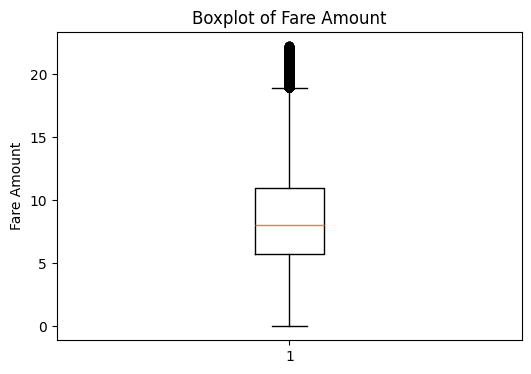

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.boxplot(df['fare_amount'])
plt.title('Boxplot of Fare Amount')
plt.ylabel('Fare Amount')
plt.show()

**3. Check the correlation**

In [ ]:
df.corr(method='pearson')


,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance
fare_amount,1.000000,0.140624,0.000134,-0.000590,-0.000964,0.000545,0.012003,0.002422
pickup_datetime,0.140624,1.000000,0.009259,-0.011328,0.008923,-0.010969,0.003011,0.026271
pickup_longitude,0.000134,0.009259,1.000000,-0.980169,0.955071,-0.942984,-0.000804,0.157839
pickup_latitude,-0.000590,-0.011328,-0.980169,1.000000,-0.942673,0.962609,-0.000640,-0.134197
dropoff_longitude,-0.000964,0.008923,0.955071,-0.942673,1.000000,-0.980724,-0.000111,0.131576
dropoff_latitude,0.000545,-0.010969,-0.942984,0.962609,-0.980724,1.000000,-0.001749,-0.112146
passenger_count,0.012003,0.003011,-0.000804,-0.000640,-0.000111,-0.001749,1.000000,-0.000383
distance,0.002422,0.026271,0.157839,-0.134197,0.131576,-0.112146,-0.000383,1.000000


In [ ]:
df.corr(method='spearman')


,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance
fare_amount,1.000000,0.142271,-0.046331,-0.070545,0.022492,-0.073379,0.019508,0.794566
pickup_datetime,0.142271,1.000000,-0.000981,-0.005039,0.001253,-0.001044,-0.015312,-0.010367
pickup_longitude,-0.046331,-0.000981,1.000000,0.573178,0.457251,0.278613,-0.020347,-0.075861
pickup_latitude,-0.070545,-0.005039,0.573178,1.000000,0.252608,0.563120,-0.014984,0.001606
dropoff_longitude,0.022492,0.001253,0.457251,0.252608,1.000000,0.520214,-0.017289,0.016205
dropoff_latitude,-0.073379,-0.001044,0.278613,0.563120,0.520214,1.000000,-0.009861,0.021288
passenger_count,0.019508,-0.015312,-0.020347,-0.014984,-0.017289,-0.009861,1.000000,0.008895
distance,0.794566,-0.010367,-0.075861,0.001606,0.016205,0.021288,0.008895,1.000000


In [ ]:
df.corr(method='kendall')


,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance
fare_amount,1.000000,0.096101,-0.031906,-0.048170,0.014577,-0.049976,0.015305,0.633424
pickup_datetime,0.096101,1.000000,-0.000646,-0.003347,0.000839,-0.000696,-0.011850,-0.006999
pickup_longitude,-0.031906,-0.000646,1.000000,0.433891,0.321584,0.195702,-0.015810,-0.050930
pickup_latitude,-0.048170,-0.003347,0.433891,1.000000,0.178413,0.404455,-0.011635,0.000111
dropoff_longitude,0.014577,0.000839,0.321584,0.178413,1.000000,0.399588,-0.013403,0.012076
dropoff_latitude,-0.049976,-0.000696,0.195702,0.404455,0.399588,1.000000,-0.007654,0.013218
passenger_count,0.015305,-0.011850,-0.015810,-0.011635,-0.013403,-0.007654,1.000000,0.006905
distance,0.633424,-0.006999,-0.050930,0.000111,0.012076,0.013218,0.006905,1.000000


In [ ]:
corr_value = df['fare_amount'].corr(df['passenger_count'])
print(corr_value)

0.012002920163386555


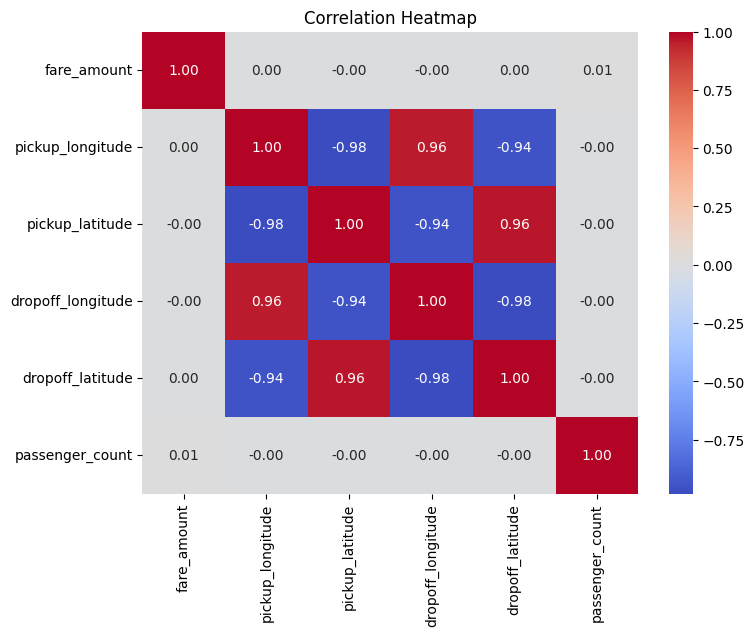

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(df[['fare_amount',
                'pickup_longitude',
                'pickup_latitude',
                'dropoff_longitude',
                'dropoff_latitude',
                'passenger_count']].corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title("Correlation Heatmap")
plt.show()


**4: Implement Linear, Ridge, and Lasso Regression**

Linear Regression

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
df = pd.DataFrame({
    'Hours_Studied': [2, 4, 6],
    'Marks': [50, 55, 65]
})

X = df[['Hours_Studied']]
y = df['Marks']

model = LinearRegression()
model.fit(X, y)

slope = model.coef_[0]
intercept = model.intercept_

df['Predicted_Marks'] = model.predict(X)

print("Slope (b1):", slope)
print("Intercept (b0):", intercept)
df


Slope (b1): 3.7499999999999987
Intercept (b0): 41.66666666666667


,Hours_Studied,Marks,Predicted_Marks
0,2,50,49.166667
1,4,55,56.666667
2,6,65,64.166667


/tmp/ipython-input-2909189487.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


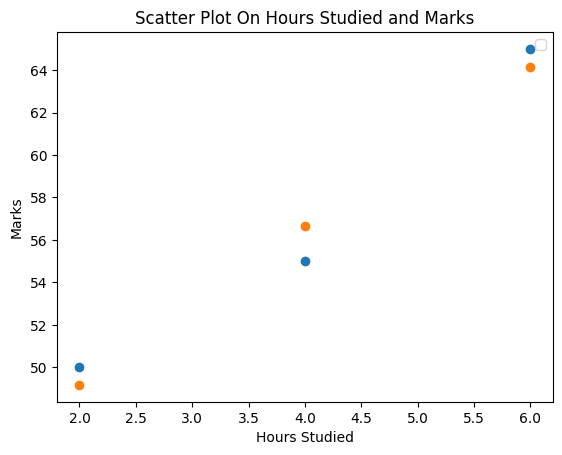

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(df['Hours_Studied'], df['Marks'])
plt.scatter(df['Hours_Studied'], df['Predicted_Marks'])

plt.xlabel('Hours Studied')
plt.ylabel('Marks')
plt.title('Scatter Plot On Hours Studied and Marks')
plt.legend()
plt.show()


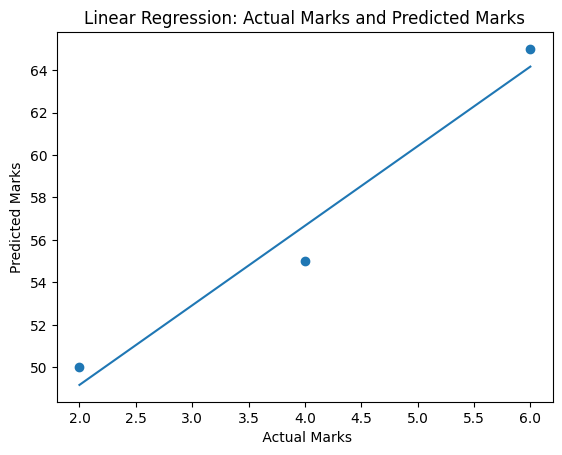

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(df['Hours_Studied'], df['Marks'])
plt.plot(df['Hours_Studied'], df['Predicted_Marks'])
plt.xlabel(" Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Linear Regression: Actual Marks and Predicted Marks")
plt.show()



Calculate MSE and R^2

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(df['Marks'], df['Predicted_Marks'])
r2 = r2_score(df['Marks'], df['Predicted_Marks'])
print("MSE:", mse)
print("R² Score:", r2)


MSE: 1.3888888888888886
R² Score: 0.9642857142857143


Linear regression (rainfall and yield)

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression

df = pd.DataFrame({
    'Rainfall': [12.3, 13.7, 14.5, 11.2, 13.2, 14.1, 12.0],
    'Yield': [6.25, 8.02, 8.42, 5.27, 7.21, 8.71, 5.68]
})

X = df[['Rainfall']]
y = df['Yield']

model = LinearRegression()
model.fit(X, y)

slope = model.coef_[0]
intercept = model.intercept_

df['Predicted_Yield'] = model.predict(X)

print("Slope (b1):", slope)
print("Intercept (b0):", intercept)
df


Slope (b1): 1.1153669724770645
Intercept (b0): -7.419770642201839


,Rainfall,Yield,Predicted_Yield
0,12.3,6.25,6.299243
1,13.7,8.02,7.860757
2,14.5,8.42,8.753050
3,11.2,5.27,5.072339
4,13.2,7.21,7.303073
5,14.1,8.71,8.306904
6,12.0,5.68,5.964633


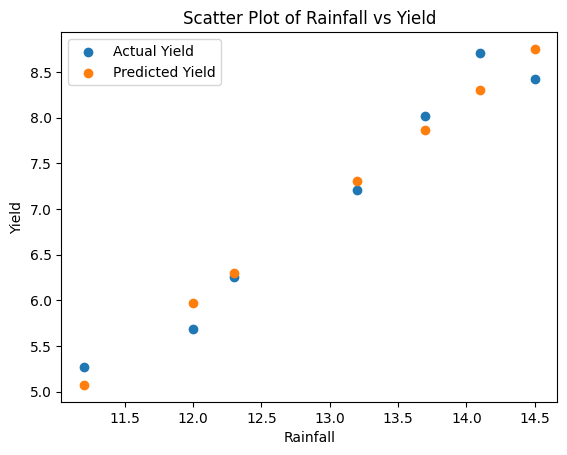

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(df['Rainfall'], df['Yield'], label='Actual Yield')
plt.scatter(df['Rainfall'], df['Predicted_Yield'], label='Predicted Yield')

plt.xlabel('Rainfall')
plt.ylabel('Yield')
plt.title('Scatter Plot of Rainfall vs Yield')
plt.legend()
plt.show()


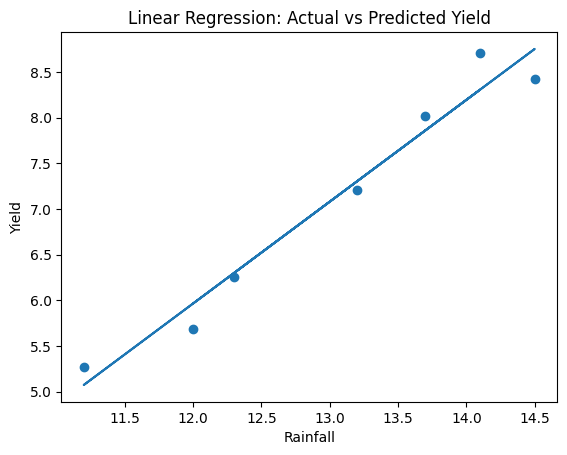

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(df['Rainfall'], df['Yield'])
plt.plot(df['Rainfall'], df['Predicted_Yield'])

plt.xlabel('Rainfall')
plt.ylabel('Yield')
plt.title("Linear Regression: Actual vs Predicted Yield")
plt.show()


Calculate MSE and R^2

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(df['Yield'], df['Predicted_Yield'])
r2 = r2_score(df['Yield'], df['Predicted_Yield'])
print("MSE:", mse)
print("R² Score:", r2)


MSE: 0.06142011795543894
R² Score: 0.9618779193395928


Logistic Regression

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

actual = [1,0,0,1,0,0,1,0,0,1]
predicted = [1,0,0,1,0,0,0,1,0,0]

cm = confusion_matrix(actual, predicted)
print("Confusion Matrix:\n", cm)

tn, fp, fn, tp = cm.ravel()
print("\nTrue Positive (TP):", tp)
print("False Positive (FP):", fp)
print("False Negative (FN):", fn)
print("True Negative (TN):", tn)

print("\nClassification Report:\n")
print(classification_report(actual, predicted))


Confusion Matrix:
 [[5 1]
 [2 2]]

True Positive (TP): 2
False Positive (FP): 1
False Negative (FN): 2
True Negative (TN): 5

Classification Report:

              precision    recall  f1-score   support

           0       0.71      0.83      0.77         6
           1       0.67      0.50      0.57         4

    accuracy                           0.70        10
   macro avg       0.69      0.67      0.67        10
weighted avg       0.70      0.70      0.69        10

